In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')
import ModuloACP as macp
%matplotlib inline

In [2]:
# Cargar datos — separador ',', decimal '.', primera columna como índice
datos = pd.read_csv('../datasets/hotel_bookings.csv', sep=',', decimal='.', index_col=0)
print('Dimensiones:', datos.shape)
datos.head()

Dimensiones: (408, 20)


,hotel,is_canceled,lead_time,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status
16303,City Hotel,1,67,May,0,3,2,0,0,0,0,A,0,No Deposit,0,Transient-Party,120.0,0,0,Canceled
17344,City Hotel,1,224,June,0,2,2,0,0,0,0,A,0,No Deposit,0,Transient,107.1,0,1,Canceled
4890,Resort Hotel,0,76,January,1,3,2,0,0,0,0,A,0,No Deposit,0,Transient,37.8,0,3,Check-Out
11142,Resort Hotel,0,72,July,0,2,2,0,0,0,0,D,0,No Deposit,0,Transient,162.0,1,1,Check-Out
18700,City Hotel,1,229,July,1,4,2,0,0,0,0,A,0,Non Refund,0,Transient,110.0,0,0,Canceled


In [3]:
# Tipos de datos por columna
print(datos.dtypes)

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_month                 object
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                            int64
babies                              int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
days_in_waiting_list                int64
customer_type                      object
adr                               float64
required_car_parking_spaces         int64
total_of_special_requests           int64
reservation_status                 object
dtype: object


In [4]:
# Codificar columnas categóricas con label encoding (orden alfabético → entero)
categoricas = ['hotel', 'arrival_date_month', 'assigned_room_type',
               'deposit_type', 'customer_type', 'reservation_status']

for col in categoricas:
    categorias = sorted(datos[col].dropna().unique())
    mapeo = {cat: i for i, cat in enumerate(categorias)}
    datos[col] = datos[col].map(mapeo)
    print(f"'{col}' → {mapeo}")

'hotel' → {'City Hotel': 0, 'Resort Hotel': 1}
'arrival_date_month' → {'April': 0, 'August': 1, 'February': 2, 'January': 3, 'July': 4, 'June': 5, 'March': 6, 'May': 7}
'assigned_room_type' → {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'K': 9}
'deposit_type' → {'No Deposit': 0, 'Non Refund': 1}
'customer_type' → {'Contract': 0, 'Group': 1, 'Transient': 2, 'Transient-Party': 3}
'reservation_status' → {'Canceled': 0, 'Check-Out': 1, 'No-Show': 2}


In [5]:
# Eliminar nulos y verificar que todas las columnas son numéricas
datos = datos.dropna()
print('Dimensiones tras limpieza:', datos.shape)
print(datos.dtypes)

Dimensiones tras limpieza: (408, 20)
hotel                               int64
is_canceled                         int64
lead_time                           int64
arrival_date_month                  int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                            int64
babies                              int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
assigned_room_type                  int64
booking_changes                     int64
deposit_type                        int64
days_in_waiting_list                int64
customer_type                       int64
adr                               float64
required_car_parking_spaces         int64
total_of_special_requests           int64
reservation_status                  int64
dtype: object


In [6]:
# Crear el modelo ACP con 5 componentes principales
acp = macp.ACP(datos, n_componentes=5)

In [7]:
# Varianza explicada por cada componente principal
var = acp.var_explicada
print('Varianza explicada por componente (%)')
acumulada = 0
for i, v in enumerate(var):
    acumulada += v
    print(f'  Componente {i}: {round(v, 2)}%  (acumulada: {round(acumulada, 2)}%)')

Varianza explicada por componente (%)
  Componente 0: 16.86%  (acumulada: 16.86%)
  Componente 1: 10.78%  (acumulada: 27.64%)
  Componente 2: 8.76%  (acumulada: 36.4%)
  Componente 3: 7.18%  (acumulada: 43.58%)
  Componente 4: 6.32%  (acumulada: 49.9%)


In [8]:
# Correlación de las variables originales con cada componente principal
print('Correlación de variables con los componentes:')
acp.correlacion_var

Correlación de variables con los componentes:


component,0,1,2,3,4
variable,,,,,
hotel,0.744769,0.207972,0.066552,-0.038114,-0.092397
is_canceled,-0.881395,0.058135,-0.116515,0.076045,0.197342
lead_time,-0.467699,0.457505,0.247398,0.041836,0.223514
arrival_date_month,0.014857,-0.027833,0.214446,-0.108817,-0.120550
stays_in_weekend_nights,0.040678,0.712922,0.481953,0.108760,0.026315
stays_in_week_nights,0.114771,0.738226,0.451551,0.097714,0.034053
adults,-0.114814,0.324603,-0.504914,0.013740,-0.271198
children,0.119142,0.241045,-0.304571,0.062229,0.174264
babies,0.162725,0.097805,-0.121950,-0.151227,0.435126


In [9]:
# Coordenadas de las observaciones en el plano principal
print('Coordenadas de las observaciones (primeras 10):')
acp.coordenadas_ind.head(10)

Coordenadas de las observaciones (primeras 10):


component,0,1,2,3,4
16303,-1.664570,-1.178216,-0.294413,-0.989219,0.156379
17344,-1.985249,-0.492112,-0.337312,0.155218,0.416963
4890,1.506138,-0.247226,0.057300,0.210822,0.357677
11142,2.327967,-0.585607,-1.394370,0.567994,-1.294191
18700,-2.988662,-0.257644,0.917973,-0.066834,-0.564323
16569,-1.323730,0.059626,-0.746620,0.100382,-0.476380
19740,-2.932074,-0.893011,-0.031200,0.025375,-0.551196
2009,-0.703165,-0.160043,-0.122482,-0.124329,-0.004841
8848,0.942838,1.174787,1.554079,1.591253,-2.265238
6150,2.793434,-1.155940,-1.611343,0.557383,-0.948544


In [10]:
# Contribución de cada observación a los componentes
print('Contribución de las observaciones (primeras 10):')
acp.contribucion_ind.head(10)

Contribución de las observaciones (primeras 10):


component,0,1,2,3,4
16303,0.002013,0.001582,0.000113,0.001691,4.664594e-05
17344,0.002864,0.000276,0.000150,0.000039,3.393515e-04
4890,0.001649,0.000068,0.000004,0.000075,2.446516e-04
11142,0.003940,0.000389,0.002714,0.000543,3.265939e-03
18700,0.006491,0.000075,0.001176,0.000008,6.250425e-04
16569,0.001273,0.000004,0.000743,0.000015,4.221367e-04
19740,0.006250,0.000906,0.000002,0.000001,5.835419e-04
2009,0.000360,0.000029,0.000026,0.000023,4.183925e-07
8848,0.000646,0.001570,0.003376,0.004308,9.973551e-03
6150,0.005678,0.001505,0.003617,0.000501,1.744880e-03


In [11]:
# Calidad de representación (cos²) de cada observación
print('Calidad de representación cos² (primeras 10):')
acp.cos2_ind.head(10)

Calidad de representación cos² (primeras 10):


component,0,1,2,3,4
16303,0.214019,0.107226,0.006695,0.075585,0.001889
17344,0.525400,0.032284,0.015168,0.003212,0.023177
4890,0.158005,0.004257,0.000229,0.003096,0.008911
11142,0.344815,0.021820,0.123705,0.020527,0.106569
18700,0.614630,0.004568,0.057986,0.000307,0.021914
16569,0.188042,0.000382,0.059821,0.001081,0.024354
19740,0.567527,0.052644,0.000064,0.000043,0.020056
2009,0.057116,0.002959,0.001733,0.001786,0.000003
8848,0.030471,0.047307,0.082785,0.086793,0.175887
6150,0.378739,0.064854,0.126020,0.015079,0.043670


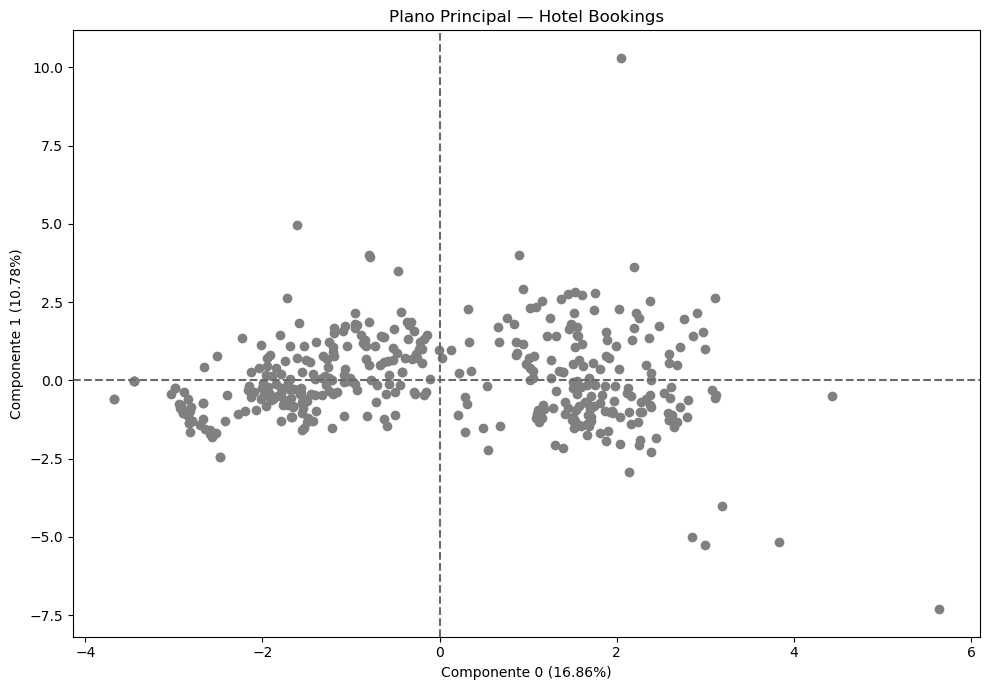

In [12]:
# Plano principal: posición de las observaciones sobre los dos primeros componentes
# Se desactivan las etiquetas (ind_labels=False) por el volumen de datos
plt.figure(figsize=(10, 7))
acp.plot_plano_principal(ejes=[0, 1], ind_labels=False, titulo='Plano Principal — Hotel Bookings')
plt.tight_layout()
plt.show()

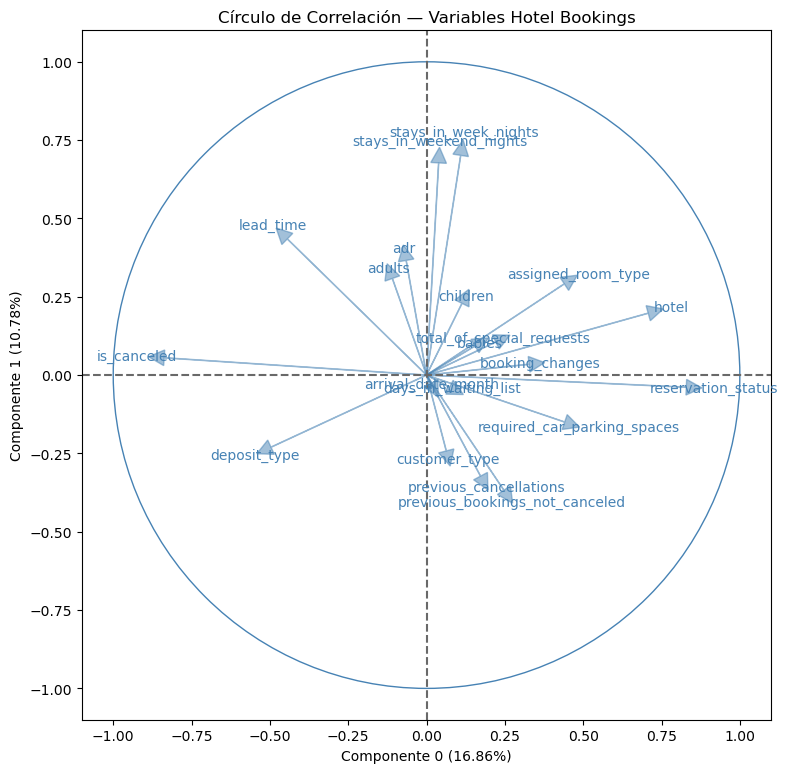

In [13]:
# Círculo de correlación: relación de las variables con los componentes
plt.figure(figsize=(8, 8))
acp.plot_circulo(ejes=[0, 1], var_labels=True, titulo='Círculo de Correlación — Variables Hotel Bookings')
plt.tight_layout()
plt.show()

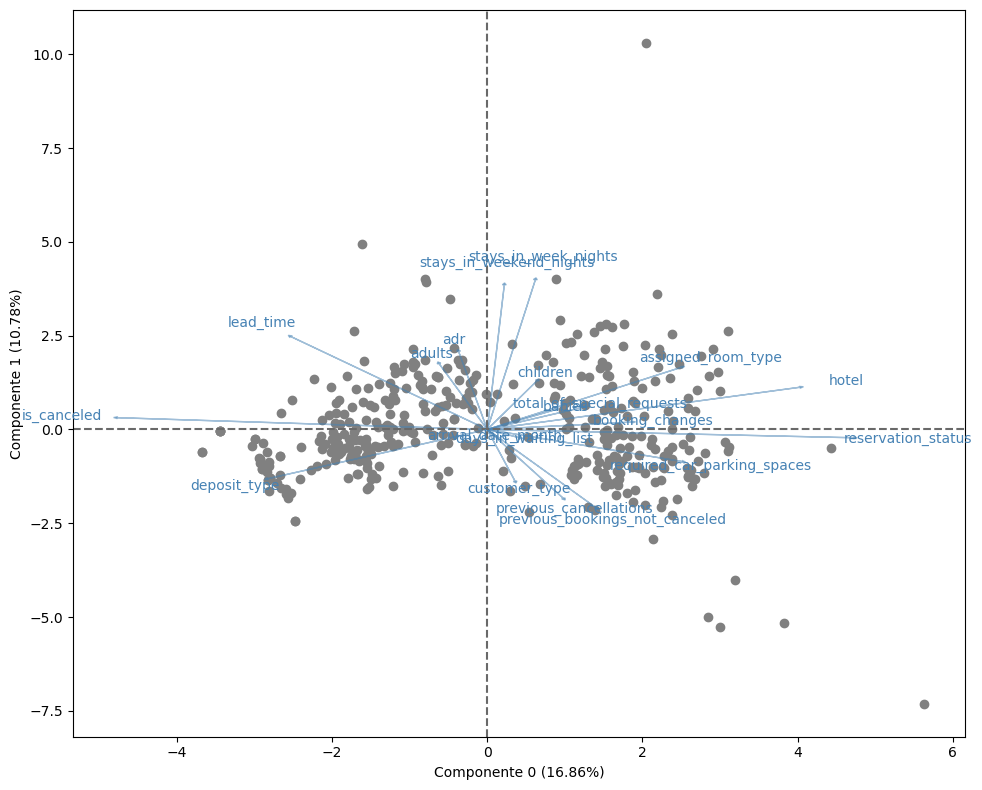

In [14]:
# Sobreposición: observaciones y variables en el mismo plano
plt.figure(figsize=(10, 8))
acp.plot_sobreposicion(ejes=[0, 1], ind_labels=False, var_labels=True,
                       titulo='Sobreposición Plano-Círculo — Hotel Bookings')
plt.tight_layout()
plt.show()

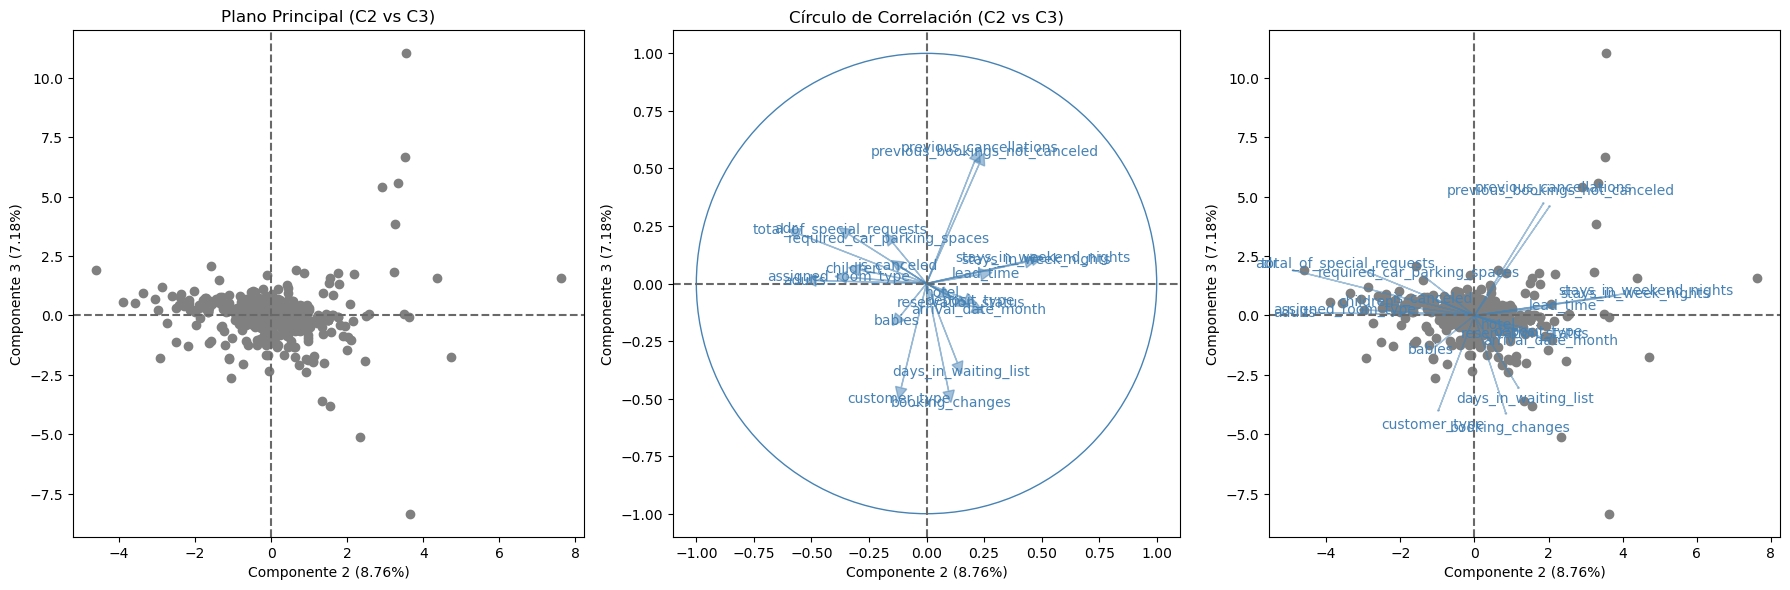

In [15]:
# Componentes 2 y 3 — segunda perspectiva del espacio de datos
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plt.sca(axes[0])
acp.plot_plano_principal(ejes=[2, 3], ind_labels=False, titulo='Plano Principal (C2 vs C3)')

plt.sca(axes[1])
acp.plot_circulo(ejes=[2, 3], var_labels=True, titulo='Círculo de Correlación (C2 vs C3)')

plt.sca(axes[2])
acp.plot_sobreposicion(ejes=[2, 3], ind_labels=False, var_labels=True, titulo='Sobreposición (C2 vs C3)')

plt.tight_layout()
plt.show()